# EDA — `master_dataset.csv`

Line-level retail orders. **Units** = `Quantity`; **revenue** = `Sales`. Aggregating to product × calendar period supports exploratory views of volume and revenue over time (the shipped product forecast is delay risk only; see `delay-forecast-system.md`).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

_cwd = Path.cwd()
NOTEBOOK_DIR = _cwd / "notebooks" if (_cwd / "notebooks").is_dir() else _cwd
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "master_dataset.csv"

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Expected dataset at {DATA_PATH}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)

PROJECT_ROOT: /Users/giahuy/Documents/GitHub/ISM
DATA_PATH: /Users/giahuy/Documents/GitHub/ISM/data/master_dataset.csv


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["OrderDate", "ShipDate"])

for col in ("RetailOrderID", "OrderID", "ProductID", "CustomerID"):
    if col in df.columns:
        df[col] = df[col].astype(str)

print("shape:", df.shape)
display(df.head())
df.info()

shape: (9994, 36)


,RetailOrderID,OrderID,OrderDate,ShipDate,ShipModeID,CustomerID,PostalCode,RetailSalesPeopleID,ProductID,Returned,...,ShipMode,Country,Region,State,City,longitude,latitude,RetailSalesPeople,year,month
0,1,CA-2016-152156,2016-08-11,2016-11-11,1,CG-12520,42420,1,FUR-BO-10001798,Not,...,Second Class,United States,South,Kentucky,Henderson,-84.270018,37.839333,Cassandra Brandow,2016,8
1,2,CA-2016-152156,2016-08-11,2016-11-11,1,CG-12520,42420,1,FUR-CH-10000454,Not,...,Second Class,United States,South,Kentucky,Henderson,-84.270018,37.839333,Cassandra Brandow,2016,8
2,3,CA-2016-138688,2016-12-06,2016-12-06,1,DV-13045,90036,2,OFF-LA-10000240,Not,...,Second Class,United States,West,California,Los Angeles,-119.417932,36.778261,Anna Andreadi,2016,12
3,4,US-2015-108966,2015-11-10,2015-11-10,2,SO-20335,33311,1,FUR-TA-10000577,Not,...,Standard Class,United States,South,Florida,Fort Lauderdale,-81.515754,27.664827,Cassandra Brandow,2015,11
4,5,US-2015-108966,2015-11-10,2015-11-10,2,SO-20335,33311,1,OFF-ST-10000760,Not,...,Standard Class,United States,South,Florida,Fort Lauderdale,-81.515754,27.664827,Cassandra Brandow,2015,11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   RetailOrderID        9994 non-null   object        
 1   OrderID              9994 non-null   object        
 2   OrderDate            9994 non-null   datetime64[ns]
 3   ShipDate             9994 non-null   datetime64[ns]
 4   ShipModeID           9994 non-null   int64         
 5   CustomerID           9994 non-null   object        
 6   PostalCode           9994 non-null   int64         
 7   RetailSalesPeopleID  9994 non-null   int64         
 8   ProductID            9994 non-null   object        
 9   Returned             9994 non-null   object        
 10  ShipStatus           9994 non-null   object        
 11  Sales                9994 non-null   float64       
 12  Quantity             9994 non-null   int64         
 13  Profit               9994 non-nul

## Data quality

Missing values, duplicate keys, and numeric summaries.

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]
print("Columns with missing values:")
display(missing_nonzero if len(missing_nonzero) else "(none)")

dup_retail = df["RetailOrderID"].duplicated().sum() if "RetailOrderID" in df.columns else None
dup_order_product = df.duplicated(subset=["OrderID", "ProductID"]).sum()
print("Duplicate RetailOrderID rows:", dup_retail)
print("Duplicate (OrderID, ProductID) rows:", dup_order_product)

num_cols = [c for c in ["Sales", "Quantity", "Profit", "Cost", "Days"] if c in df.columns]
display(df[num_cols].describe())

Columns with missing values:


'(none)'

Duplicate RetailOrderID rows: 0
Duplicate (OrderID, ProductID) rows: 8


,Sales,Quantity,Profit,Cost,Days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,28.656896,201.201105,34.609065
std,623.245101,2.225110,234.260108,550.839414,55.058389
min,0.444000,1.000000,-6599.978000,0.554400,0.000000
25%,17.280000,2.000000,1.728750,12.688200,2.000000
50%,54.490000,3.000000,8.666500,41.664000,4.000000
75%,209.940000,5.000000,29.364000,182.226300,61.000000
max,22638.480000,14.000000,8399.976000,24449.558400,214.000000


## Demand and sales over time

`order_period` = month-start from `OrderDate`. Totals are sums over all line items in that month.

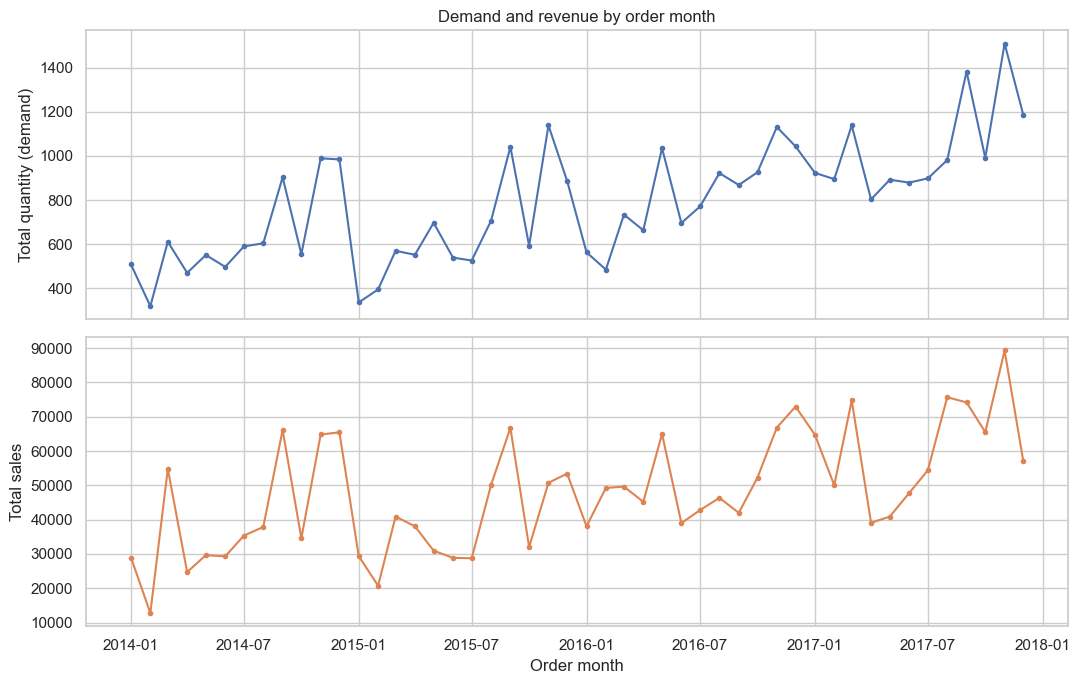

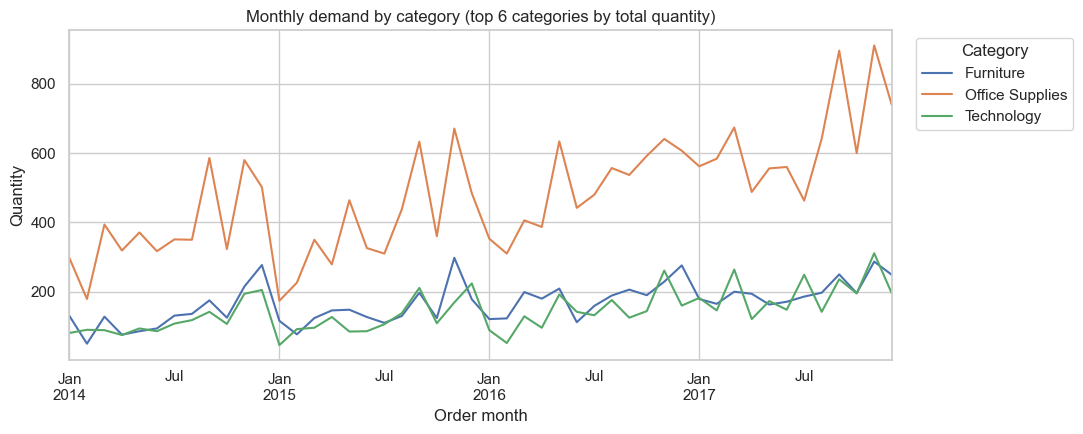

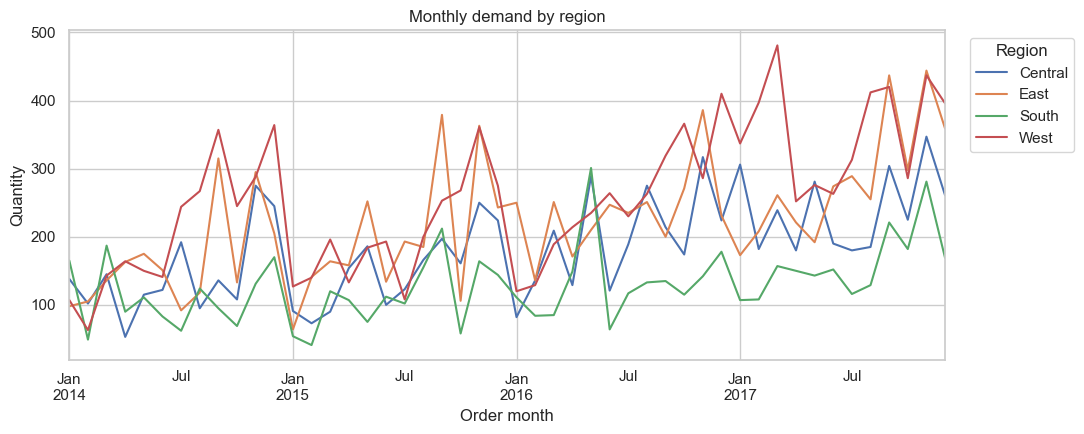

In [4]:
df["order_period"] = df["OrderDate"].dt.to_period("M").dt.to_timestamp(how="start")

monthly = (
    df.groupby("order_period", as_index=False)
    .agg(demand=("Quantity", "sum"), revenue=("Sales", "sum"))
    .sort_values("order_period")
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(monthly["order_period"], monthly["demand"], marker="o", ms=3)
axes[0].set_ylabel("Total quantity (demand)")
axes[0].set_title("Demand and revenue by order month")
axes[1].plot(monthly["order_period"], monthly["revenue"], color="C1", marker="o", ms=3)
axes[1].set_ylabel("Total sales")
axes[1].set_xlabel("Order month")
plt.tight_layout()
plt.show()

top_cats = df.groupby("Category")["Quantity"].sum().nlargest(6).index.tolist()
df_top = df[df["Category"].isin(top_cats)]
by_cat = (
    df_top.groupby(["order_period", "Category"])["Quantity"]
    .sum()
    .unstack("Category")
    .fillna(0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 4.5))
by_cat.plot(ax=ax, linewidth=1.5)
ax.set_title("Monthly demand by category (top 6 categories by total quantity)")
ax.set_xlabel("Order month")
ax.set_ylabel("Quantity")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

by_region = (
    df.groupby(["order_period", "Region"])["Quantity"]
    .sum()
    .unstack("Region")
    .fillna(0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 4.5))
by_region.plot(ax=ax, linewidth=1.5)
ax.set_title("Monthly demand by region")
ax.set_xlabel("Order month")
ax.set_ylabel("Quantity")
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Quarterly return-rate and unit margin-ratio views.
def _resolve_col(frame: pd.DataFrame, preferred: str) -> str | None:
    if preferred in frame.columns:
        return preferred
    wanted = preferred.lower()
    for col in frame.columns:
        if col.lower() == wanted:
            return col
    return None

order_date_col = _resolve_col(df, "OrderDate")
order_id_col = _resolve_col(df, "OrderID")
returned_col = _resolve_col(df, "Returned")
unit_sp_col = _resolve_col(df, "UnitSP")
unit_cp_col = _resolve_col(df, "UnitCP")

required = {
    "OrderDate": order_date_col,
    "OrderID": order_id_col,
    "Returned": returned_col,
    "UnitSP": unit_sp_col,
    "UnitCP": unit_cp_col,
}
missing = [name for name, resolved in required.items() if resolved is None]

if missing:
    print(f"Skipping quarterly return/margin charts; missing columns: {missing}")
else:
    df_quarter = df.copy()
    df_quarter["order_quarter"] = (
        df_quarter[order_date_col].dt.to_period("Q-DEC").dt.to_timestamp(how="start")
    )

    total_orders = (
        df_quarter.groupby("order_quarter")[order_id_col]
        .nunique()
        .rename("total_orders")
    )
    returned_mask = df_quarter[returned_col].astype(str).str.strip().str.lower().eq("yes")
    returned_orders = (
        df_quarter.loc[returned_mask]
        .groupby("order_quarter")[order_id_col]
        .nunique()
        .rename("returned_orders")
    )

    quarterly_return = pd.concat([total_orders, returned_orders], axis=1).fillna(0)
    quarterly_return["return_rate"] = np.where(
        quarterly_return["total_orders"] > 0,
        quarterly_return["returned_orders"] / quarterly_return["total_orders"],
        np.nan,
    )
    quarterly_return = quarterly_return.reset_index().sort_values("order_quarter")

    quarterly_ratio = (
        df_quarter.groupby("order_quarter", as_index=False)
        .agg(unit_sp=(unit_sp_col, "mean"), unit_cp=(unit_cp_col, "mean"))
        .sort_values("order_quarter")
    )
    quarterly_ratio["sp_cp_ratio"] = np.where(
        quarterly_ratio["unit_cp"].notna() & quarterly_ratio["unit_cp"].ne(0),
        quarterly_ratio["unit_sp"] / quarterly_ratio["unit_cp"],
        np.nan,
    )

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    axes[0].plot(
        quarterly_return["order_quarter"],
        quarterly_return["return_rate"],
        marker="o",
        linewidth=1.8,
        label="Return rate",
    )
    axes[0].set_title("Quarterly return rate (returned orders / total orders)")
    axes[0].set_ylabel("Return rate")
    axes[0].set_ylim(0, 1)
    axes[0].legend(loc="upper left")

    axes[1].plot(
        quarterly_ratio["order_quarter"],
        quarterly_ratio["sp_cp_ratio"],
        marker="o",
        linewidth=1.8,
        color="C2",
        label="UnitSP / UnitCP",
    )
    axes[1].axhline(1.0, color="C3", linestyle="--", linewidth=1.2, label="Break-even (ratio=1)")

    ratio_outliers = quarterly_ratio[quarterly_ratio["sp_cp_ratio"] < 1].copy()
    if not ratio_outliers.empty:
        axes[1].scatter(
            ratio_outliers["order_quarter"],
            ratio_outliers["sp_cp_ratio"],
            color="C3",
            s=50,
            zorder=3,
            label="Loss outlier (ratio < 1)",
        )
        for _, row in ratio_outliers.iterrows():
            quarter_label = pd.Period(row["order_quarter"], freq="Q-DEC").strftime("%YQ%q")
            axes[1].annotate(
                quarter_label,
                (row["order_quarter"], row["sp_cp_ratio"]),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color="C3",
            )

    axes[1].set_title("Quarterly UnitSP/UnitCP ratio with loss outliers")
    axes[1].set_xlabel("Order quarter")
    axes[1].set_ylabel("UnitSP / UnitCP")
    axes[1].legend(loc="upper left")

    plt.tight_layout()
    plt.show()

## Sparsity

- **Time coverage**: calendar span of `OrderDate` and how many distinct months / quarters appear.
- **Panel density**: build the full Cartesian grid (every product × every calendar quarter in the span). **Density** = share of cells with demand &gt; 0; **sparsity** = 1 − density. After reindexing with zeros, **zero share** = fraction of grid cells with exactly zero aggregated quantity.
- **Product × region × quarter**: same idea on a finer grid (typically much sparser).
- **Concentration**: how much of total demand sits in the top SKUs (Pareto-style).

OrderDate min: 2014-01-02 max: 2017-12-30
Distinct calendar months (with ≥1 row): 48
Months in inclusive calendar span: 48
Distinct quarters in span (Q-DEC): 16 [Period('2014Q1', 'Q-DEC'), Period('2014Q2', 'Q-DEC'), Period('2014Q3', 'Q-DEC'), Period('2014Q4', 'Q-DEC'), Period('2015Q1', 'Q-DEC'), Period('2015Q2', 'Q-DEC'), Period('2015Q3', 'Q-DEC'), Period('2015Q4', 'Q-DEC'), Period('2016Q1', 'Q-DEC'), Period('2016Q2', 'Q-DEC'), Period('2016Q3', 'Q-DEC'), Period('2016Q4', 'Q-DEC'), Period('2017Q1', 'Q-DEC'), Period('2017Q2', 'Q-DEC'), Period('2017Q3', 'Q-DEC'), Period('2017Q4', 'Q-DEC')]


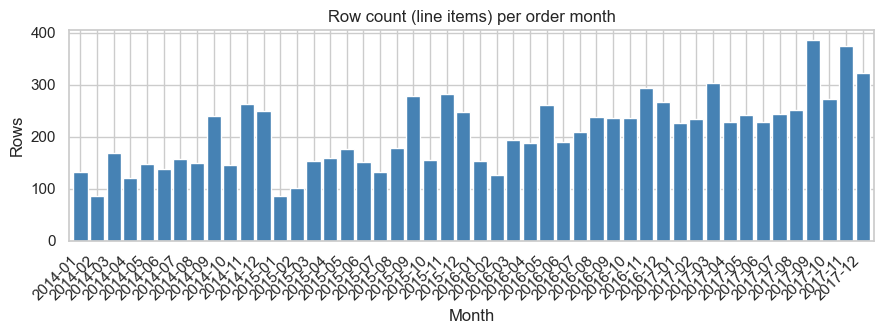

In [5]:
order_min, order_max = df["OrderDate"].min(), df["OrderDate"].max()
q_start = order_min.to_period("Q")
q_end = order_max.to_period("Q")
all_quarters = pd.period_range(q_start, q_end, freq="Q-DEC")
n_months_calendar = len(
    pd.period_range(order_min.to_period("M"), order_max.to_period("M"), freq="M")
)
n_months_observed = df["OrderDate"].dt.to_period("M").nunique()

print("OrderDate min:", order_min.date(), "max:", order_max.date())
print("Distinct calendar months (with ≥1 row):", n_months_observed)
print("Months in inclusive calendar span:", n_months_calendar)
print("Distinct quarters in span (Q-DEC):", len(all_quarters), list(all_quarters))

orders_per_month = df.groupby(df["OrderDate"].dt.to_period("M")).size()
fig, ax = plt.subplots(figsize=(9, 3.5))
orders_per_month.astype(int).plot(kind="bar", ax=ax, color="steelblue", width=0.85)
ax.set_title("Row count (line items) per order month")
ax.set_xlabel("Month")
ax.set_ylabel("Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
df["year_quarter"] = df["OrderDate"].dt.to_period("Q-DEC")
products = np.sort(df["ProductID"].unique())
n_products = len(products)
n_periods_q = len(all_quarters)

pq = (
    df.groupby(["ProductID", "year_quarter"])["Quantity"]
    .sum()
    .rename("demand")
)
idx_pq = pd.MultiIndex.from_product(
    [products, all_quarters], names=["ProductID", "year_quarter"]
)
pq_full = pq.reindex(idx_pq, fill_value=0)
n_cells_pq = len(pq_full)
n_active_pq = int((pq_full > 0).sum())
density_pq = n_active_pq / n_cells_pq
zero_share_pq = int((pq_full == 0).sum()) / n_cells_pq

print("=== Product × quarter (Q-DEC) ===")
print("Products:", n_products, "Quarters in span:", n_periods_q)
print("Grid cells (product × quarter):", n_cells_pq)
print("Cells with demand > 0:", n_active_pq)
print("Density (active / grid):", round(density_pq, 6))
print("Sparsity (1 - density):", round(1 - density_pq, 6))
print("Share of cells with zero demand (full grid):", round(zero_share_pq, 6))

=== Product × quarter (Q-DEC) ===
Products: 1862 Quarters in span: 16
Grid cells (product × quarter): 29792
Cells with demand > 0: 8345
Density (active / grid): 0.280109
Sparsity (1 - density): 0.719891
Share of cells with zero demand (full grid): 0.719891


In [7]:
regions = np.sort(df["Region"].dropna().unique())
n_regions = len(regions)
idx_pqr = pd.MultiIndex.from_product(
    [products, regions, all_quarters],
    names=["ProductID", "Region", "year_quarter"],
)
pqr = (
    df.groupby(["ProductID", "Region", "year_quarter"])["Quantity"]
    .sum()
    .rename("demand")
)
pqr_full = pqr.reindex(idx_pqr, fill_value=0)
n_cells_pqr = len(pqr_full)
n_active_pqr = int((pqr_full > 0).sum())
density_pqr = n_active_pqr / n_cells_pqr

print("=== Product × region × quarter ===")
print("Regions:", n_regions, list(regions))
print("Grid cells:", n_cells_pqr)
print("Cells with demand > 0:", n_active_pqr)
print("Density:", round(density_pqr, 8))
print("Sparsity:", round(1 - density_pqr, 8))
print("Share of cells with zero demand:", round(float((pqr_full == 0).mean()), 8))

=== Product × region × quarter ===
Regions: 4 ['Central', 'East', 'South', 'West']
Grid cells: 119168
Cells with demand > 0: 9510
Density: 0.0798033
Sparsity: 0.9201967
Share of cells with zero demand: 0.9201967


Total demand (sum of Quantity): 37873
Distinct ProductID: 1862
Share of demand from top 10% of SKUs: 0.2137
Share of demand from top 20% of SKUs: 0.3715


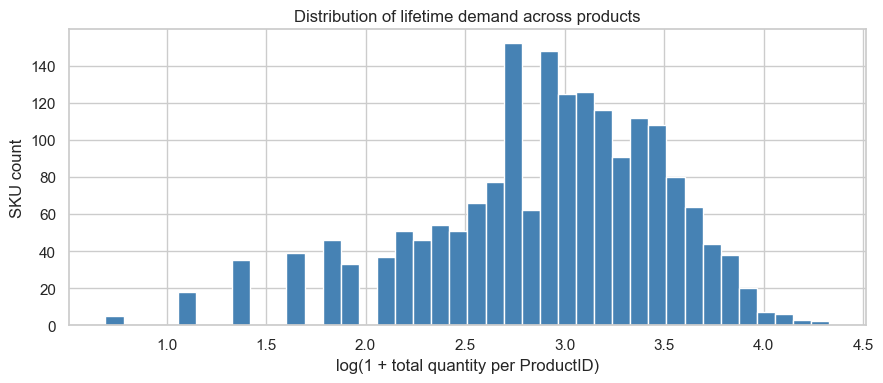

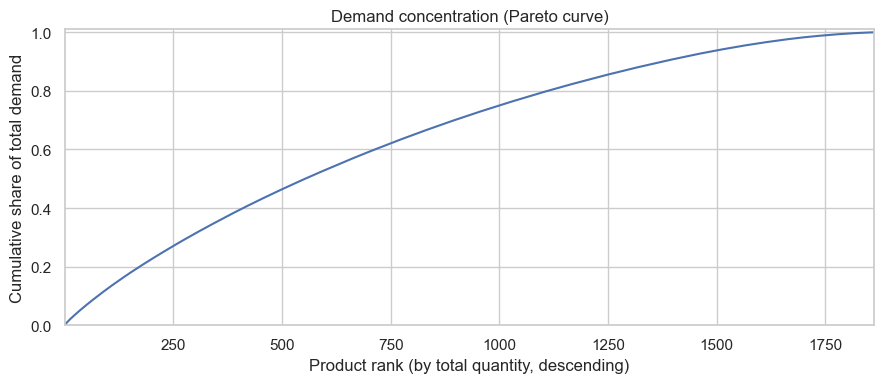

In [8]:
totals_by_product = df.groupby("ProductID")["Quantity"].sum().sort_values(ascending=False)
total_demand = totals_by_product.sum()
n_sku = len(totals_by_product)

def top_share(frac: float) -> float:
    k = max(1, int(np.ceil(frac * n_sku)))
    return float(totals_by_product.head(k).sum() / total_demand)

print("Total demand (sum of Quantity):", int(total_demand))
print("Distinct ProductID:", n_sku)
print("Share of demand from top 10% of SKUs:", round(top_share(0.10), 4))
print("Share of demand from top 20% of SKUs:", round(top_share(0.20), 4))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.log1p(totals_by_product.values)
ax.hist(x, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("log(1 + total quantity per ProductID)")
ax.set_ylabel("SKU count")
ax.set_title("Distribution of lifetime demand across products")
plt.tight_layout()
plt.show()

cum = totals_by_product.cumsum() / total_demand
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(cum) + 1), cum.values, color="C0")
ax.set_xlabel("Product rank (by total quantity, descending)")
ax.set_ylabel("Cumulative share of total demand")
ax.set_title("Demand concentration (Pareto curve)")
ax.set_xlim(1, len(cum))
ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.show()

## Related dimensions

Categorical mix and correlations among numeric fields.

--- Returned ---


Returned
Not    9194
Yes     800
Name: count, dtype: int64

--- ShipStatus ---


ShipStatus
On-Time    5413
Late       4581
Name: count, dtype: int64

--- Segment ---


Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

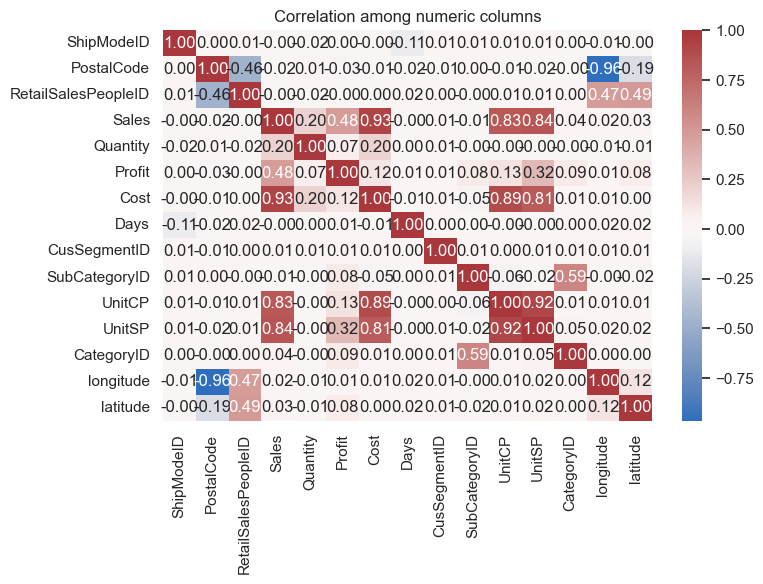

In [9]:
for col in ("Returned", "ShipStatus", "Segment"):
    if col in df.columns:
        print(f"--- {col} ---")
        display(df[col].value_counts(dropna=False))

num_for_corr = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ("year", "month")]
if len(num_for_corr) >= 2:
    cm = df[num_for_corr].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
    ax.set_title("Correlation among numeric columns")
    plt.tight_layout()
    plt.show()

## Summary

- See printed bullets below after a full run (date range, row count, sparsity, concentration).

In [10]:
summary_lines = [
    f"- Rows (line items): {len(df):,}",
    f"- OrderDate range: {order_min.date()} → {order_max.date()}",
    f"- Distinct months with data: {n_months_observed}",
    f"- Product × quarter grid: density={density_pq:.4%}, sparsity={1 - density_pq:.4%}, zero cells={zero_share_pq:.4%}",
    f"- Product × region × quarter: density={density_pqr:.4%}, sparsity={1 - density_pqr:.4%}",
    f"- Top 10% of SKUs account for {top_share(0.10):.1%} of total quantity; top 20% account for {top_share(0.20):.1%}.",
]
print("\n".join(summary_lines))

- Rows (line items): 9,994
- OrderDate range: 2014-01-02 → 2017-12-30
- Distinct months with data: 48
- Product × quarter grid: density=28.0109%, sparsity=71.9891%, zero cells=71.9891%
- Product × region × quarter: density=7.9803%, sparsity=92.0197%
- Top 10% of SKUs account for 21.4% of total quantity; top 20% account for 37.1%.
